### LIBRARIES

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#import seaborn 
import seaborn as sns
%matplotlib inline
# to ignore/remove all warnings
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import mutual_info_regression

###### IMPORTING THE DATASET INTO WORKING SPACE(NOTEBOOK) FROM THE ORIGINAL SOURCE

In [2]:
#importing the dataset from original source
df1= pd.read_csv('price_prediction_batch_23.csv')

In [3]:
df1

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,NaN,Hybrid,3.5,186005 km,6,Automatic,4x4,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6,Tiptronic,4x4,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4,Variator,Front,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,NaN,Hybrid,2.5,168966 km,4,Automatic,4x4,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,NaN,Petrol,1.3,91901 km,4,Automatic,Front,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4,Manual,Rear,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4,Tiptronic,Front,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4,Automatic,Front,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4,Automatic,Front,Left wheel,Black,4


In [4]:
#Displays the first 5 rows of the dataset
df1.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,NaN,Hybrid,3.5,186005 km,6,Automatic,4x4,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6,Tiptronic,4x4,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4,Variator,Front,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,NaN,Hybrid,2.5,168966 km,4,Automatic,4x4,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,NaN,Petrol,1.3,91901 km,4,Automatic,Front,Left wheel,Silver,4


In [5]:
#Displays the last 5 rows of the dataset
df1.tail()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4,Manual,Rear,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4,Tiptronic,Front,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4,Automatic,Front,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4,Automatic,Front,Left wheel,Black,4
19236,45813273,470,753,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923 km,4,Automatic,Front,Left wheel,White,12


In [6]:
#Displays the total number of the rows and columns in the given Dataset.
df1.shape

(19237, 17)

In [7]:
# It displays the number of columns,data type of the data and the memory usage.
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                19237 non-null  int64 
 1   Price             19237 non-null  int64 
 2   Levy              19237 non-null  object
 3   Manufacturer      19237 non-null  object
 4   Model             19237 non-null  object
 5   Prod. year        19237 non-null  int64 
 6   Category          19237 non-null  object
 7   Leather interior  19233 non-null  object
 8   Fuel type         19237 non-null  object
 9   Engine volume     19237 non-null  object
 10  Mileage           19237 non-null  object
 11  Cylinders         19237 non-null  int64 
 12  Gear box type     19237 non-null  object
 13  Drive wheels      19237 non-null  object
 14  Wheel             19237 non-null  object
 15  Color             19237 non-null  object
 16  Airbags           19237 non-null  int64 
dtypes: int64(5),

### CONCLUTION
The data we imported has 19237 rows and 17 columns.

## SECTION 1(a): Converting Levy column into integer

In [8]:
# It checks the type of data in each column of the dataset
df1.dtypes

ID                   int64
Price                int64
Levy                object
Manufacturer        object
Model               object
Prod. year           int64
Category            object
Leather interior    object
Fuel type           object
Engine volume       object
Mileage             object
Cylinders            int64
Gear box type       object
Drive wheels        object
Wheel               object
Color               object
Airbags              int64
dtype: object

In [9]:
# conveting the data types into category form 

df1['Category']=df1['Category'].astype('category')
df1['Leather interior']=df1['Leather interior'].astype('category')
df1['Fuel type']=df1['Fuel type'].astype('category')
df1['Wheel']=df1['Wheel'].astype('category')
df1['Drive wheels']=df1['Drive wheels'].astype('category')
df1['Manufacturer']=df1['Manufacturer'].astype('category')
df1['Color']=df1['Color'].astype('category')
df1['Gear box type']=df1['Gear box type'].astype('category')


#### OBSERVATIONS

I used this code to convert object data types into category data type from the dataset.

Categorical data types are useful when dealing with columns that have a limited, fixed set of possible values, as they can improve memory usage and speed up certain operations compared to using plain text or numeric data types.

This can be helpful for memory optimization and can also provide better support for certain types of analyses and operations.

In [10]:
# Removing the non numeric values,ie 'Turbo' using .replace()
df1['Engine volume'] = df1['Engine volume'].str.replace('Turbo', '').astype(float)

In [11]:
# Confirming the presence of `-` value in Levy column
df1.Levy.value_counts().keys()

Index(['-', '765', '891', '639', '640', '1017', '781', '707', '642', '836',
       ...
       '2364', '557', '1103', '5666', '2177', '3156', '2908', '1279', '1719',
       '1901'],
      dtype='object', name='Levy', length=559)

In [12]:
# Replacing the unique value('-') in Levy column and converting it to integer type.
import numpy as np
df1.Levy=pd.to_numeric(df1.Levy, errors='coerce').fillna(0)
df1.Levy=df1.Levy.astype('int64')
df1.dtypes

ID                     int64
Price                  int64
Levy                   int64
Manufacturer        category
Model                 object
Prod. year             int64
Category            category
Leather interior    category
Fuel type           category
Engine volume        float64
Mileage               object
Cylinders              int64
Gear box type       category
Drive wheels        category
Wheel               category
Color               category
Airbags                int64
dtype: object

### OBSEVARTION:

In the first code i checked the presence of the unique value in the 'Levy' column('-').

The second code is intended to replace the unique value ('-') in the 'Levy' column, convert the values to numeric, and then convert the column to the 'int64' data type.

After executing this code, the 'Levy' column in the DataFrame df1 contained integer values, and the data types of all columns was  displayed using df1.dtypes. 

###      SECTION 1(b): Converting Mileage column to integer and checking for NAN values

In [13]:
# Checking the unique values present in `Mileage` column
df1.Mileage.value_counts().keys()

Index(['0 km', '200000 km', '150000 km', '160000 km', '100000 km', '180000 km',
       '1000 km', '170000 km', '120000 km', '130000 km',
       ...
       '101920 km', '92003 km', '115232 km', '93500 km', '61146 km',
       '63083 km', '28750 km', '25077 km', '77452 km', '186923 km'],
      dtype='object', name='Mileage', length=7687)

In [14]:
# removing 'km' from the Mileage column
df1.Mileage =df1.Mileage.str.replace('km', '')
df1.Mileage = df1.Mileage.astype('int64')
print(df1.Mileage)

0        186005
1        192000
2        200000
3        168966
4         91901
          ...  
19232    300000
19233    161600
19234    116365
19235     51258
19236    186923
Name: Mileage, Length: 19237, dtype: int64


#### CONCLUSION:
From the above output cell, we can see that this Mileage column is having numeric values with string part km and due to which pandas read the whole column as object type or categorical instead of numeric. 
So,i removed the string km and convert the Mileage column into Integer type.

In [15]:
#Checking the first 5 rows of the dataset
df1.head

<bound method NDFrame.head of              ID  Price  Levy   Manufacturer    Model  Prod. year   Category  \
0      45654403  13328  1399          LEXUS   RX 450        2010       Jeep   
1      44731507  16621  1018      CHEVROLET  Equinox        2011       Jeep   
2      45774419   8467     0          HONDA      FIT        2006  Hatchback   
3      45769185   3607   862           FORD   Escape        2011       Jeep   
4      45809263  11726   446          HONDA      FIT        2014  Hatchback   
...         ...    ...   ...            ...      ...         ...        ...   
19232  45798355   8467     0  MERCEDES-BENZ  CLK 200        1999      Coupe   
19233  45778856  15681   831        HYUNDAI   Sonata        2011      Sedan   
19234  45804997  26108   836        HYUNDAI   Tucson        2010       Jeep   
19235  45793526   5331  1288      CHEVROLET  Captiva        2007       Jeep   
19236  45813273    470   753        HYUNDAI   Sonata        2012      Sedan   

      Leather interio

In [16]:
#checking the missing value in the dataset
df1.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    4
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [17]:
#displays the statistical summary of the dataset
df1.describe()

,ID,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,632.528669,2010.912824,2.307990,1.532236e+06,4.582991,6.582627
std,9.365914e+05,1.905813e+05,567.721688,5.668673,0.877805,4.840387e+07,1.199933,4.320168
min,2.074688e+07,1.000000e+00,0.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,0.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,642.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,917.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,4.581665e+07,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


In [18]:
#checks for NaN values
df1.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    4
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [19]:
#checking the value counts available in Leader interior datatype.
df1['Leather interior'].value_counts()


Leather interior
Yes    13950
No      5283
Name: count, dtype: int64

In [20]:
# Filling in NaN values with a specific value
#Assigning mode value at null positions
df1['Leather interior'].fillna(df1['Leather interior'].mode()[0], inplace=True)

In [21]:
#Checking if the NaN values have been removed
df1.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [22]:
df1.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')

##        SECTION 2(a): Checking for duplicates and removing them if any

In [23]:
import pandas as pd

# Assuming df1 is your DataFrame

# Step 1: Check for duplicates
duplicates = df1[df1.duplicated()]

print("\nNumber of Rows Before Removing Duplicates:", len(df1))

# Step 2: View duplicated rows
if not duplicates.empty:
    print("Duplicated Rows:")
    print(duplicates)
else:
    print("No Duplicates Found")

# Step 3: Remove duplicates
df1= df1.drop_duplicates()

# Step 4: Verify that duplicates are removed

print("Number of Rows After Removing Duplicates:", len(df1))



Number of Rows Before Removing Duplicates: 19237
Duplicated Rows:
             ID  Price  Levy   Manufacturer        Model  Prod. year  \
425    45815372   7840     0  MERCEDES-BENZ        E 200        1998   
1581   45815363   8781     0         TOYOTA          Ist        2002   
1697   45732125  18503     0         TOYOTA        Prius        2010   
1972   45507765  20385     0  MERCEDES-BENZ      CLS 500        2005   
2131   45815363   8781     0         TOYOTA          Ist        2002   
...         ...    ...   ...            ...          ...         ...   
18974  45815465   2352  1273          LEXUS       IS 350        2015   
19137  45810466  15125   642      CHEVROLET      Orlando        2012   
19200  45725908  36065   640  MERCEDES-BENZ  CLA 250 AMG        2013   
19203  45761487  13485   645         TOYOTA        Prius        2011   
19210  45732939   8311   642        HYUNDAI       Sonata        2012   

        Category Leather interior Fuel type  Engine volume  Mileage 

In [24]:
#prints out the row in order
df1.reset_index(inplace=True)

In [25]:
df1.drop(['index','ID'], axis=1, inplace=True)
df1.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6,Tiptronic,4x4,Left wheel,Black,8
2,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4,Automatic,Front,Left wheel,Silver,4


In [26]:
df1.shape

(18924, 16)

### OBSERVATIONS:

1.The df1.duplicated() method is used to identify rows that are duplicate, and the result is store in variable 'duplicates'

2.The resulting DataFrame duplicates contain rows that have identical values across all columns.


3.Viewing Duplicated Rows:If there are duplicated rows, the code prints them, including the column values.
If no duplicates are found, it prints "No Duplicates Found."In this case there are 313 rows duplicated,i went a head removing the duplicate which returned back 18924 row hence initial dataset was consisting of 19237 rows before removing the duplicates.

4.df1.drop('index', 'ID', axis=1, inplace=True):This line drops the specified columns 'index' and 'ID' from the DataFrame df1.
The parameter axis=1 indicates that the operation should be performed along the columns.

5.The parameter inplace=True modifies the DataFrame df1 in place, meaning that the changes are applied directly to the DataFrame without creating a new copy.

6.df1.head():This line displays the first few rows of the modified DataFrame df1 after dropping the specified columns.


###           SECTION 2(b): CHECKING FOR OUTLIERS USING BOXPLOT AND STATISTICAL METHOD

In [27]:
#It shows the statistical summary of numeric types.
df1.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.892400e+04,18924.000000,18924.000000,18924.000000,1.892400e+04,18924.000000,18924.000000
mean,1.858744e+04,632.886493,2010.914236,2.306251,1.555373e+06,4.580216,6.568379
std,1.921356e+05,568.273736,5.665749,0.877591,4.880221e+07,1.200223,4.322323
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5.331000e+03,0.000000,2009.000000,1.800000,7.019575e+04,4.000000,4.000000
50%,1.317200e+04,642.000000,2012.000000,2.000000,1.264000e+05,4.000000,6.000000
75%,2.206300e+04,917.000000,2015.000000,2.500000,1.891198e+05,4.000000,12.000000
max,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


<Axes: xlabel='Levy'>

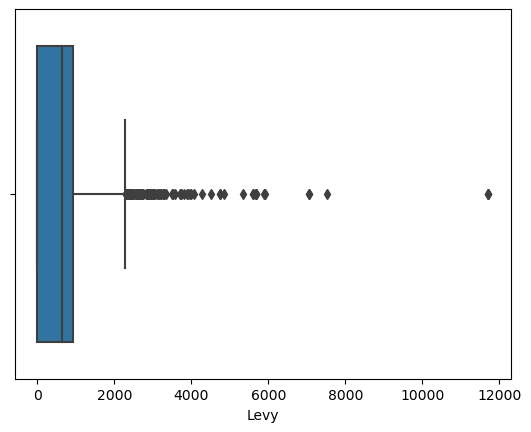

In [28]:
sns.boxplot(data=df1,x=df1['Levy'])

<Axes: xlabel='Prod. year'>

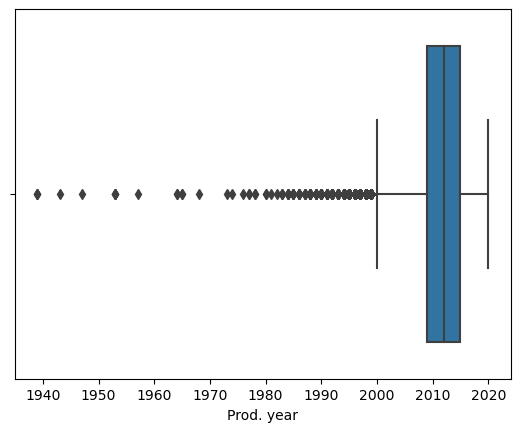

In [29]:
sns.boxplot(data=df1,x=df1['Prod. year'])

In [30]:
q1=np.quantile(df1['Levy'],0.25)
q3=np.quantile(df1['Levy'],0.75)
IQR=q3-q1
print("The First quartile is", q1)
print("The Third quartile is", q3)
print("The Interquartilerange is", IQR)

The First quartile is 0.0
The Third quartile is 917.0
The Interquartilerange is 917.0


In [31]:
# applying limits to update instances of the outliers in category Levy
lower_limit=q1-(1.5*IQR)
upper_limit=q3+(1.5*IQR)
df1['Levy']=np.where(df1['Levy'] < lower_limit,lower_limit,df1['Levy'])
df1['Levy']=np.where(df1['Levy'] > upper_limit,upper_limit,df1['Levy'])

<Axes: xlabel='Levy'>

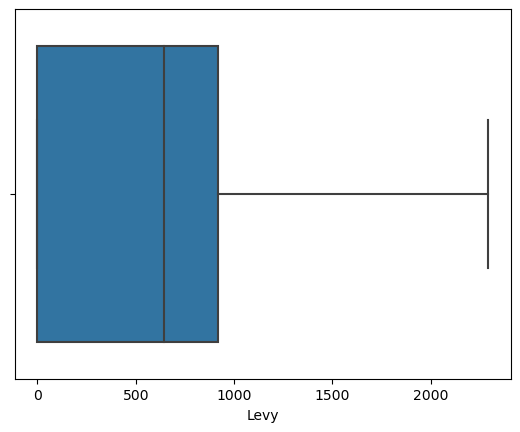

In [32]:
sns.boxplot(data=df1,x=df1['Levy'])

In [33]:
q1=np.quantile(df1['Prod. year'],0.25)
q3=np.quantile(df1['Prod. year'],0.75)
IQR=q3-q1
print("The First quartile is", q1)
print("The Third quartile is", q3)
print("The Interquartilerange is", IQR)

The First quartile is 2009.0
The Third quartile is 2015.0
The Interquartilerange is 6.0


In [34]:
# applying limits to update instances of the outliers in category Prod. year
lower_limit=q1-(1.5*IQR)
upper_limit=q3+(1.5*IQR)
df1['Prod. year']=np.where(df1['Prod. year'] < lower_limit,lower_limit,df1['Prod. year'])
df1['Prod. year']=np.where(df1['Prod. year'] > upper_limit,upper_limit,df1['Prod. year'])

<Axes: xlabel='Prod. year'>

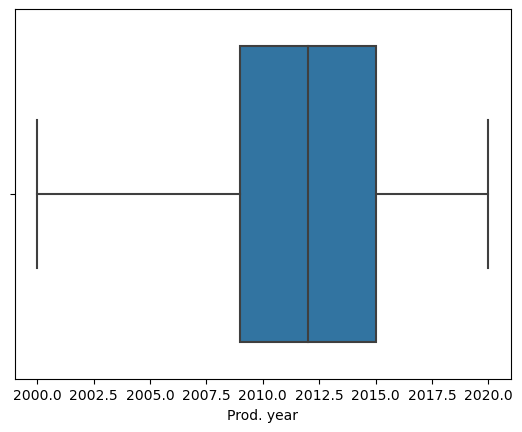

In [35]:
sns.boxplot(data=df1,x=df1['Prod. year'])

In [36]:
### STATISTICAL METHOD TO COMPUTE THE UPPER AND LOWER LIMITS using MEAN AND STANDARD DEVIATION
print("For PRICE")

upper_limit = df1['Price'].mean() + 3*df1['Price'].std()
lower_limit = df1['Price'].mean() - 3*df1['Price'].std()

print("Highest allowed:",upper_limit)
print("Lowest allowed:",lower_limit)

df1["Price"] = np.where (df1["Price"] <lower_limit, lower_limit,df1['Price'])
df1["Price"] = np.where (df1["Price"] >upper_limit, upper_limit,df1['Price'])

For PRICE
Highest allowed: 594994.3274467641
Lowest allowed: -557819.4569119934


In [37]:
### STATISTICAL METHOD TO COMPUTE THE UPPER AND LOWER LIMITS using MEAN AND STANDARD DEVIATION
print("For MILEAGE")

upper_limit = df1['Mileage'].mean() + 3*df1['Mileage'].std()
lower_limit = df1['Mileage'].mean() - 3*df1['Mileage'].std()

print("Highest allowed:",upper_limit)
print("Lowest allowed:",lower_limit)

df1["Mileage"] = np.where (df1["Mileage"] <lower_limit, lower_limit,df1['Mileage'])
df1["Mileage"] = np.where (df1["Mileage"] >upper_limit, upper_limit,df1['Mileage'])

For MILEAGE
Highest allowed: 147961988.68361148
Lowest allowed: -144851243.2457548


#### OBSERVATION:
The columns Levy and Prod.year both had the outliers,which are the datapoint that fall outside the 'Whisker'of the plot.

In the Levy column the outliers falls in right side of the plot while in Prod.year column the outliers falls at the left side of the plot

In levy column the distance from median to minimum is greater than the distance from median to maximum hence making it negatively skewed.While the prod.year is Symetric because the median of the boxplot is equidistant from the maximum and minimum value.

I applied statistical method to find out the exact values of upper and lower limits since we can't quess the values.

I have used the interquartile range (IQR) method to detect and remove outliers in the ‘Levy’and 'Prod.year' column of the dataset,this calculates the upper and lower limits based on the IQR, identifies outlier indices using Boolean arrays, and then removes the corresponding rows from the DataFrame, resulting in a new DataFrame with outliers excluded. 

The before and after shapes of the DataFrame are printed for comparison.

The second plots were printed without outliers indicating that the outliers were removed after applying the statistical method to remove them. 

###             SECTION 2(C): DRAWING COUNTPLOT

In [38]:
Categorical=df1.columns[df1.dtypes=="category"].to_list()
print(Categorical)

['Manufacturer', 'Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']


##### Observation:

The code printed out 8 categorical features in total from the dataset

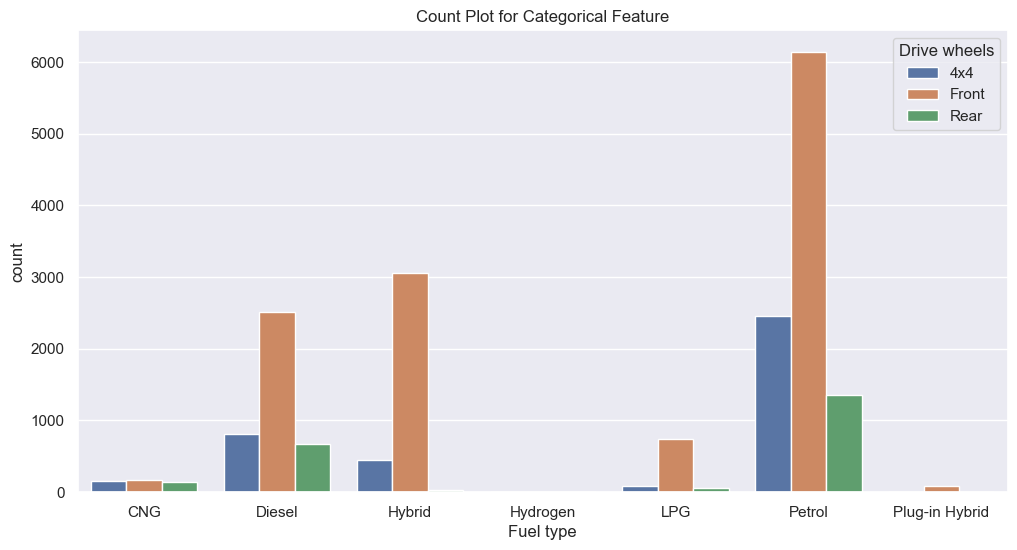

In [39]:
sns.set(style="darkgrid")
plt.figure(figsize=(12,6))
sns.countplot(x='Fuel type',data=df1, hue='Drive wheels')
plt.title('Count Plot for Categorical Feature')

plt.show()

### OBSERVATIONS

Count Plot:The count plot displays the distribution of categories within the 'Fuel type' feature.

The x-axis represents the categories of 'Fuel type,' and the height of the bars represents the count of occurrences for each category.
The plot is segmented by the 'Drive wheels' feature, and different colors are used to distinguish between categories.

Fuel Types:Examine the distribution of different fuel types such as Gasoline, Diesel, Hybrid, etc., represented on the x-axis.
Identify which fuel types are more prevalent in the dataset.

Drive Wheels Segmentation:The plot is further segmented by the 'Drive wheels' feature, and each fuel type is differentiated by hue.
Observe the count of each fuel type for different drive wheel configurations, such as Front-Wheel Drive (FWD), Rear-Wheel Drive (RWD), or All-Wheel Drive (AWD).

Insights:The plot allows comparison of the distribution of fuel types across different drive wheel configurations.

It helps in understanding whether certain fuel types are more prevalent in vehicles with specific drive wheel configurations.

By examining the distribution patterns, you can gain insights into the relationship between fuel type and drive wheel configuration, which may be useful for further analysis or decision-making.

Visualization :The plot is well-formatted with a dark grid background, making it easy to distinguish between different bars and segments.

The title clearly indicates the purpose of the plot, which is to visualize the count of vehicles based on fuel type and drive wheel configuration.

Overall, the count plot effectively presents the distribution of fuel types while considering the segmentation by drive wheel configurations. It provides valuable insights into the relationship between these categorical features within the dataset.

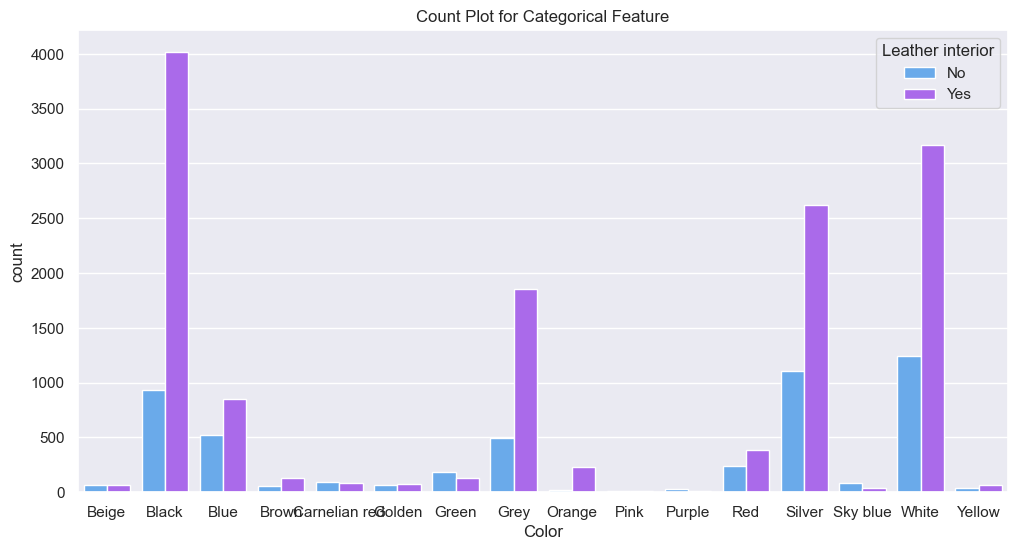

In [40]:
sns.set(style="darkgrid")
plt.figure(figsize=(12,6))
sns.countplot(x='Color',data=df1, hue='Leather interior',palette='cool')
plt.title('Count Plot for Categorical Feature')

plt.show()

#### OBSERVATION

The resulting plot is a count plot that shows the distribution of colors ('Color' column) with a breakdown based on the presence or absence of leather interiors ('Leather interior' column).

Each bar represents the count of observations for a particular color, and the different colors within each bar represent the counts based on the 'Leather interior' category.

The highest bar is at 4000 count while the lowest is around 100 count accordind above countplot diagram.

This visualization helps in understanding the distribution of categories and their relationships within the dataset.


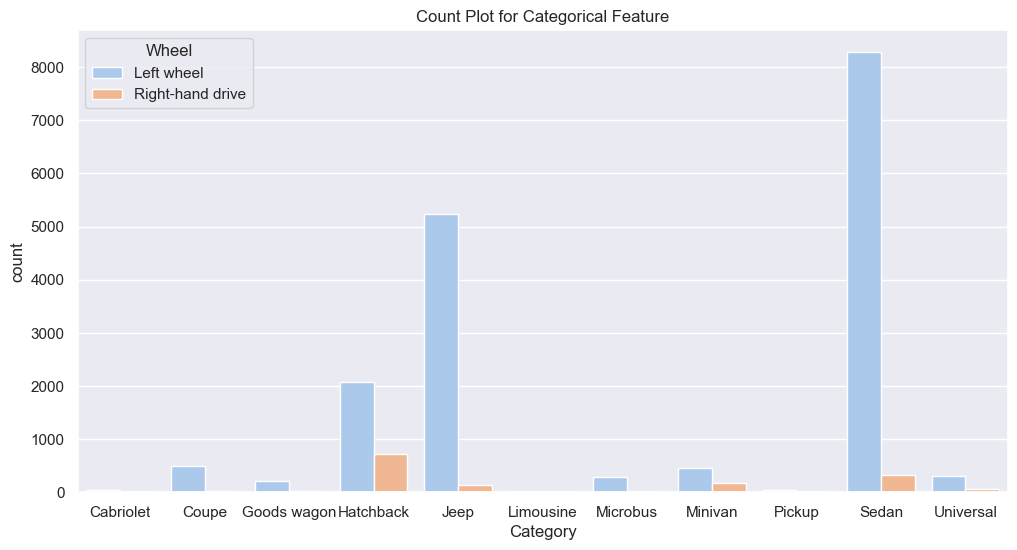

In [41]:
sns.set(style="darkgrid")
plt.figure(figsize=(12,6))
sns.countplot(x='Category',data=df1,hue='Wheel',palette='pastel')
plt.title('Count Plot for Categorical Feature')

plt.show()

#### OBSERVATIONS 

The resulting plot is a count plot that shows the distribution of categories ('Category' column) with a breakdown based on the type of wheel ('Wheel' column). 

Each bar represents the count of observations for a particular category, and the different colors within each bar represent the counts based on the 'Wheel' category.

This type of plot is useful for visualizing the relationship between two categorical variables ('Category' and 'Wheel' in this case) and understanding how they are distributed within each category. 

The hue parameter adds another dimension to the plot, making it easy to compare the distribution of 'Wheel' types across different 'Category' values.

Overall, the plot provides a comprehensive view of the distribution of vehicle categories and their corresponding wheel types, aiding in visual exploration and analysis of the dataset.

### SECTION 2 (d): Histogram and skewness

In [42]:
df1.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,18924.000000,18924.000000,18924.000000,18924.000000,1.892400e+04,18924.000000,18924.000000
mean,17212.319910,625.483249,2011.148753,2.306251,3.080869e+05,4.580216,6.568379
std,19664.033424,520.625821,4.868423,0.877591,4.689850e+06,1.200223,4.322323
min,1.000000,0.000000,2000.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5331.000000,0.000000,2009.000000,1.800000,7.019575e+04,4.000000,4.000000
50%,13172.000000,642.000000,2012.000000,2.000000,1.264000e+05,4.000000,6.000000
75%,22063.000000,917.000000,2015.000000,2.500000,1.891198e+05,4.000000,12.000000
max,594994.327447,2292.500000,2020.000000,20.000000,1.479620e+08,16.000000,16.000000


####          SKEWNESS

In [43]:
# computing the skewness of numeric columns in the DataFrame df1.
df1.skew(numeric_only=True)

Price             6.807031
Levy              0.523792
Prod. year       -0.861465
Engine volume     2.208051
Mileage          30.625062
Cylinders         2.107707
Airbags           0.086344
dtype: float64

In [44]:
#Just df1.skew gives a warning,so selected columns need to be given
df1[['Mileage','Price','Cylinders','Airbags']].skew()

Mileage      30.625062
Price         6.807031
Cylinders     2.107707
Airbags       0.086344
dtype: float64

13172.0
1.0
594994.3274467641
17212.31991029065
Price column seems to be skewed
6.807031114344894
Price feature is right skewed


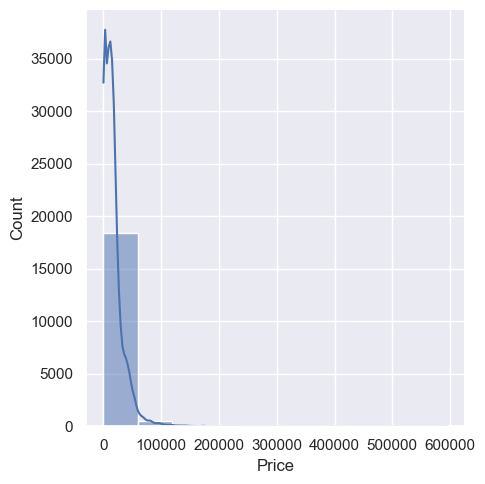

In [45]:
#Using seaborn library to plot the histogram
sns.displot(x='Price',data=df1,bins=10,kde=True)
print(df1['Price'].median())
print(df1['Price'].min())
print(df1['Price'].max())
print(df1['Price'].mean())
print('Price column seems to be skewed')

#computing skewness
print(df1['Price'].skew())
print('Price feature is right skewed')

### Obseravation 

The histogram plot and statistics suggest that the 'Price' column is right-skewed, as indicated by its skewness value.

This means that the distribution has a longer right tail, and the majority of prices are concentrated on the lower end.

-1.3885182381135917


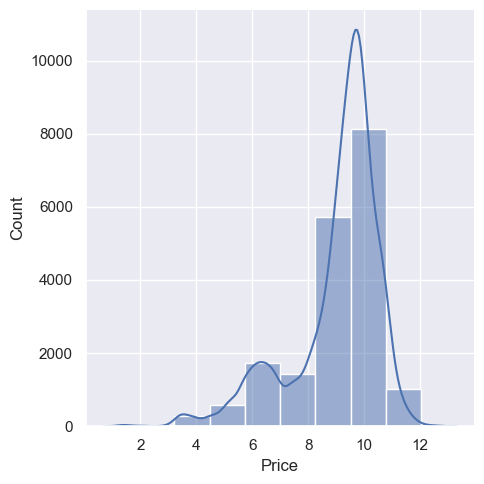

In [46]:
#Applying transformation method if need be
#log function used
Price_log=np.log(df1['Price'] +1)
print(Price_log.skew())
sns.displot(x=Price_log,bins=10, kde=True)
df1['Price']=Price_log


#### Observation

The provided code applies a logarithmic transformation to the 'Price' column in the DataFrame df1 and then prints the skewness of the transformed column. 

Additionally, it plots a histogram of the transformed column using Seaborn's 'displot'.

The log-transformed 'Price' column is likely applied to reduce the skewness in the distribution, as indicated by the printed skewness value.

The histogram plot visually represents the transformed distribution, and the updated 'Price' column in the DataFrame reflects the transformation.

In [47]:
#checking if the log value will appear
#np.log(0.5)
np.log(5)

1.6094379124341003

###          SECTION 3(a): JOINT PLOT WITH HUE PARAMETER

In [48]:
df1.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,18924.000000,18924.000000,18924.000000,18924.000000,1.892400e+04,18924.000000,18924.000000
mean,9.028758,625.483249,2011.148753,2.306251,3.080869e+05,4.580216,6.568379
std,1.584297,520.625821,4.868423,0.877591,4.689850e+06,1.200223,4.322323
min,0.693147,0.000000,2000.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,8.581482,0.000000,2009.000000,1.800000,7.019575e+04,4.000000,4.000000
50%,9.485925,642.000000,2012.000000,2.000000,1.264000e+05,4.000000,6.000000
75%,10.001703,917.000000,2015.000000,2.500000,1.891198e+05,4.000000,12.000000
max,13.296309,2292.500000,2020.000000,20.000000,1.479620e+08,16.000000,16.000000


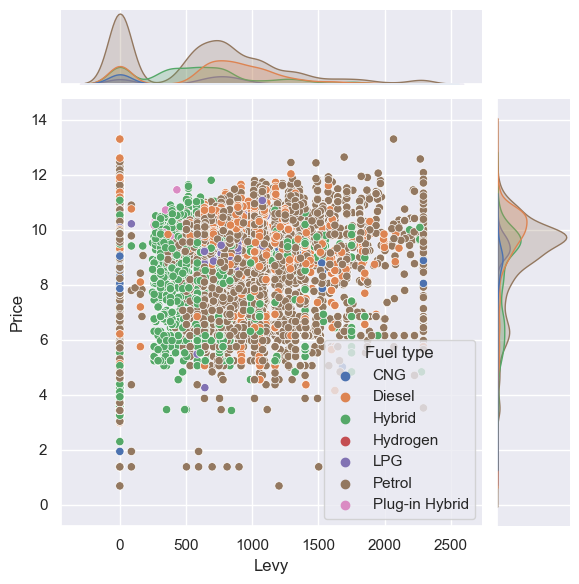

In [49]:
# Creating a joint plot with a hue parameter
sns.jointplot(data=df1,x='Levy',y='Price',hue='Fuel type')
plt.show()
    

#### OBSERVATIONS

The main plot is a scatter plot with 'Levy' on the x-axis and 'Price' on the y-axis. Each point in the scatter plot represents an observation in the dataset, with 'Levy' values on the horizontal axis and 'Price' values on the vertical axis.

Along the top and right margins of the scatter plot, there are histograms showing the distribution of 'Levy' and 'Price' values, respectively. These histograms provide insights into the individual distributions of each variable.

Hue Parameter: The points in the scatter plot are color-coded based on the 'Fuel type' column. This means that each data point is assigned a color according to its 'Fuel type'. The legend likely shows the mapping of colors to different fuel types.

The joint plot helps visualize the relationship between 'Levy' and 'Price' column, and the hue parameter allows the exploration of how the distribution varies based on the fuel type.

Overall, the joint plot with a hue parameter provides a visual representation of the relationship between 'Levy', 'Price', and 'Fuel type', allowing for easy interpretation and analysis of the dataset.

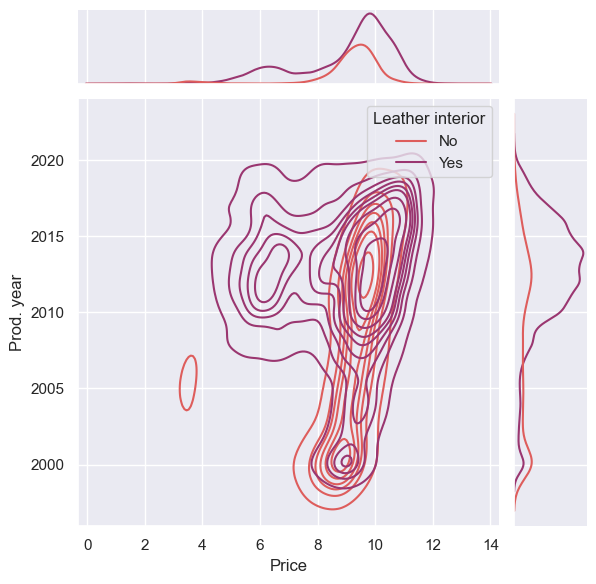

In [50]:
# Creating a joint plot with a hue parameter
sns.jointplot(data=df1,x='Price',y='Prod. year',hue='Leather interior', kind='kde',palette='flare')
plt.show()

#### OBSERVATIONS

The main plot displays contours representing the density of data points, with two histogram along the top and right margins of the contours.

The contours are differentiated by the hue parameter 'Leather interior', with different shades or colors representing the presence or absence of leather interiors.

The x-axis represents the 'Price' of the vehicles, while the y-axis represents the 'Production Year'. 

The contours provide insights into the density patterns of vehicles with and without leather interiors across different price ranges and production years. 

The hue parameter allows for the differentiation of contours based on the presence or absence of leather interiors. This enables the comparison of density patterns and distributions between vehicles with and without leather interiors.

The 'kind' parameter set to 'kde' enables Kernel Density Estimation, providing a smoothed representation of the data distribution. This helps to identify overall trends and patterns more easily.

The 'flare' palette is used to differentiate hues, providing a visually appealing representation of the data.

###          SECTION 3(b): APPLYIN SCALING METHOD FOR INDEPENDENT FEATURES

In [51]:
 import pandas as pd
from sklearn.preprocessing import StandardScaler,MinMaxScaler

# Creating a StandardScaler instance
scaler = StandardScaler()

# Selecting specific columns for standardization (Prod. year, Price, Cylinders,Airbags)
df1_scaled=scaler.fit_transform(df1[['Prod. year','Mileage','Levy','Cylinders','Airbags']].to_numpy())
df1_scaled

# Creating a new DataFrame with standardized values
df1_scaled1= pd.DataFrame(df1_scaled, columns=['Prod. year','Mileage','Levy','Cylinders','Airbags'])
df1_scaled1



,Prod. year,Mileage,Levy,Cylinders,Airbags
0,-0.235966,-0.026032,1.485783,1.182965,1.256677
1,-0.030555,-0.024753,0.753952,1.182965,0.331224
2,-1.057609,-0.023048,-1.201438,-0.483436,-1.056955
3,-0.030555,-0.029665,0.454305,-0.483436,-1.519681
4,0.585677,-0.046098,-0.344754,-0.483436,-0.594228
...,...,...,...,...,...
18919,-2.290074,-0.001724,-1.201438,-0.483436,-0.362865
18920,-0.030555,-0.031236,0.394760,-0.483436,0.331224
18921,-0.235966,-0.040881,0.404364,-0.483436,-0.594228
18922,-0.852198,-0.054764,1.272573,-0.483436,-0.594228


In [52]:
scaler = StandardScaler() # a=0, b=1
column_list = ['Levy','Prod. year','Engine volume','Mileage','Cylinders','Airbags']
X = df1[ column_list ]
X_scaled = scaler.fit_transform(X)
X_scaled_df1 = pd.DataFrame(X_scaled, columns=column_list)
print(X_scaled[-10:,:])

[[ 8.21181029e-01  5.85676824e-01  1.36029224e+00 -1.89897797e-02
   1.18296544e+00  1.25667715e+00]
 [ 2.35207140e+00 -6.46787718e-01  1.36029224e+00 -3.94933242e-02
   1.18296544e+00  1.25667715e+00]
 [-1.20143825e+00 -6.46787718e-01 -9.18733927e-01 -3.37091907e-02
  -4.83436077e-01 -1.31501921e-01]
 [ 3.74880886e-02 -3.05554471e-02 -5.76880003e-01 -1.62452644e-04
  -4.83436077e-01  1.25667715e+00]
 [ 8.25022661e-01  3.80266067e-01  1.36029224e+00 -4.27075847e-02
   1.18296544e+00  1.25667715e+00]
 [-1.20143825e+00 -2.29007377e+00 -3.48977386e-01 -1.72437768e-03
  -4.83436077e-01 -3.62865100e-01]
 [ 3.94759870e-01 -3.05554471e-02  1.06827846e-01 -3.12356985e-02
  -4.83436077e-01  3.31224437e-01]
 [ 4.04363950e-01 -2.35966204e-01 -3.48977386e-01 -4.08812519e-02
  -4.83436077e-01 -5.94228280e-01]
 [ 1.27257280e+00 -8.52198475e-01 -3.48977386e-01 -5.47641533e-02
  -4.83436077e-01 -5.94228280e-01]
 [ 2.44936220e-01  1.74855310e-01  1.06827846e-01 -2.58360223e-02
  -4.83436077e-01  1.2566

### FOR PRICE

In [53]:
q1 = np.quantile(df1['Price'], 0.25)
q3 = np.quantile(df1['Price'], 0.75)
print(q1,q3)
IQR = q3-q1
IQR

y1 = df1['Price']
y1_new = (y1-np.median(y1))/IQR
print(y1_new.max())
print(y1_new.min())

8.5814816812986 10.001702600033083
2.682951801351987
-6.191133550197859


## OBSERVATIONS

###### The resulting DataFrame df1_scaled1 contains the standardized values of the specified columns.

The selected columns in df1 (Levy, Prod. year, Engine volume, Mileage, Cylinders, Airbags) are standardized using StandardScaler.

The standardized values are printed for the last 10 rows, providing insight into the standardized representation of the selected features.

The output of print(X_scaled[-10:, :]) shows the scaled values for the specified columns in the last 10 rows of the DataFrame X. The values are standardized, meaning they have a mean of 0 and a standard deviation of 1 after the scaling process.

For Price:

The code calculates the interquartile range (IQR) of the 'Price' column and then normalizes the 'Price' values using the median and IQR.

The printed maximum and minimum normalized values give an idea of the range of the normalized 'Price' values after this transformation.

###            section 3(c): Converting categorical features into numeric using appropriate encoding techniques

In [54]:
#prints the first 5 rows of the dataset
df1.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,9.497697,1399.0,LEXUS,RX 450,2010.0,Jeep,Yes,Hybrid,3.5,186005.0,6,Automatic,4x4,Left wheel,Silver,12
1,9.718482,1018.0,CHEVROLET,Equinox,2011.0,Jeep,No,Petrol,3.0,192000.0,6,Tiptronic,4x4,Left wheel,Black,8
2,9.044050,0.0,HONDA,FIT,2006.0,Hatchback,No,Petrol,1.3,200000.0,4,Variator,Front,Right-hand drive,Black,2
3,8.190909,862.0,FORD,Escape,2011.0,Jeep,Yes,Hybrid,2.5,168966.0,4,Automatic,4x4,Left wheel,White,0
4,9.369649,446.0,HONDA,FIT,2014.0,Hatchback,Yes,Petrol,1.3,91901.0,4,Automatic,Front,Left wheel,Silver,4


In [55]:
from sklearn.preprocessing import OrdinalEncoder

### For "Leather interior"
print(df1['Leather interior'].unique())
mapping = {"No":1, "Yes":0 }
df1["Leather interior"] = df1["Leather interior"].map(mapping)

df1['Leather interior']

['Yes', 'No']
Categories (2, object): ['No', 'Yes']


0        0
1        1
2        1
3        0
4        0
        ..
18919    0
18920    0
18921    0
18922    0
18923    0
Name: Leather interior, Length: 18924, dtype: category
Categories (2, int64): [1, 0]

### OBSERVATION

The provided code is using a mapping dictionary to replace values in the "Leather interior" column and then displaying the modified column.

The code modifies the "Leather interior" column by replacing "Yes" with 0 and "No" with 1, effectively converting it into a binary variable (0 for "Yes" and 1 for "No").

The resulting "Leather interior" column is displayed after the replacement.

In [56]:

from sklearn.preprocessing import LabelEncoder

print(df1['Manufacturer'].unique())
manuf_encoder = LabelEncoder()
print(df1['Manufacturer'])

manuf_encoder = manuf_encoder.fit(df1['Manufacturer']) ### Mapping Table created
print(manuf_encoder.classes_)

manuf_values = manuf_encoder.transform(df1['Manufacturer'])

#### Re-assign encoded values to the 'Manufacturer' column
df1['Manufacturer'] = manuf_values

# For 'Model' column
df1['Model'].value_counts()
modl_encoder = LabelEncoder()
modl_values = modl_encoder.fit_transform(df1['Model'])
df1['Model'] = modl_values


# For 'Category' column
df1['Category'].value_counts()
cat_encoder = LabelEncoder()
cat_values = cat_encoder.fit_transform(df1['Category'])
df1['Category'] = cat_values


# For 'Fuel type' column
df1['Fuel type'].value_counts()
fuel_encoder = LabelEncoder()
fuel_values = fuel_encoder.fit_transform(df1['Fuel type'])
df1['Fuel type'] = fuel_values


# For 'Gear box type' column
df1['Gear box type'].value_counts()
gear_encoder = LabelEncoder()
gear_values = gear_encoder.fit_transform(df1['Gear box type'])
df1['Gear box type'] = gear_values


# For 'Drive wheels' column
df1['Drive wheels'].value_counts()
driv_encoder = LabelEncoder()
driv_values = driv_encoder.fit_transform(df1['Drive wheels'])
df1['Drive wheels'] = driv_values


# For 'Wheel' column
df1['Wheel'].value_counts()
wheel_encoder = LabelEncoder()
wheel_values = wheel_encoder.fit_transform(df1['Wheel'])
df1['Wheel'] = wheel_values


# For 'Color' column
df1['Color'].value_counts()
colo_encoder = LabelEncoder()
colo_values = colo_encoder.fit_transform(df1['Color'])
df1['Color'] = colo_values

['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', ..., 'ROLLS-ROYCE', 'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL']
Length: 65
Categories (65, object): ['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', ..., 'VOLKSWAGEN', 'VOLVO', 'ZAZ', 'სხვა']
0                LEXUS
1            CHEVROLET
2                HONDA
3                 FORD
4                HONDA
             ...      
18919    MERCEDES-BENZ
18920          HYUNDAI
18921          HYUNDAI
18922        CHEVROLET
18923          HYUNDAI
Name: Manufacturer, Length: 18924, dtype: category
Categories (65, object): ['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', ..., 'VOLKSWAGEN', 'VOLVO', 'ZAZ', 'სხვა']
['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'CITROEN' 'DAEWOO' 'DAIHATSU' 'DODGE'
 'FERRARI' 'FIAT' 'FORD' 'GAZ' 'GMC' 'GREATWALL' 'HAVAL' 'HONDA' 'HUMMER'
 'HYUNDAI' 'INFINITI' 'ISUZU' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LANCIA'
 'LAND ROVER' 'LEXUS' 'LINCOLN' 'MASERATI'

#### OBSERVATIONS:

Categorical columns in df1 (such as 'Manufacturer', 'Model', 'Category', etc.) are being encoded using LabelEncoder.

The original categorical values are replaced with numeric labels, making them suitable for machine learning models that require numerical input.

The mapping between original values and encoded values is stored in the classes_ attribute of each LabelEncoder object.

This encoding is useful for algorithms that expect numerical input, but it's important to note that it introduces an ordinal relationship between categories that may not exist in the original data.

In [57]:
df1.head

<bound method NDFrame.head of            Price    Levy  Manufacturer  Model  Prod. year  Category  \
0       9.497697  1399.0            32   1242      2010.0         4   
1       9.718482  1018.0             8    658      2011.0         4   
2       9.044050     0.0            21    684      2006.0         3   
3       8.190909   862.0            16    661      2011.0         4   
4       9.369649   446.0            21    684      2014.0         3   
...          ...     ...           ...    ...         ...       ...   
18919   9.044050     0.0            36    385      2000.0         1   
18920   9.660269   831.0            23   1334      2011.0         9   
18921  10.170035   836.0            23   1442      2010.0         4   
18922   8.581482  1288.0             8    456      2007.0         4   
18923   6.154858   753.0            23   1334      2012.0         9   

      Leather interior  Fuel type  Engine volume   Mileage  Cylinders  \
0                    0          2           

###        SECTION 3(d): Computing correlarion among all independent features and demonstrating using Heatmap method

In [58]:
## y is dependent variable and X is set of independent variables.
y = df1['Price']

# Load X Variables into a Pandas Dataframe with columns
X = df1.drop(['Price'], axis = 1)

print(y.shape)
print(X.shape)

(18924,)
(18924, 15)


<Axes: >

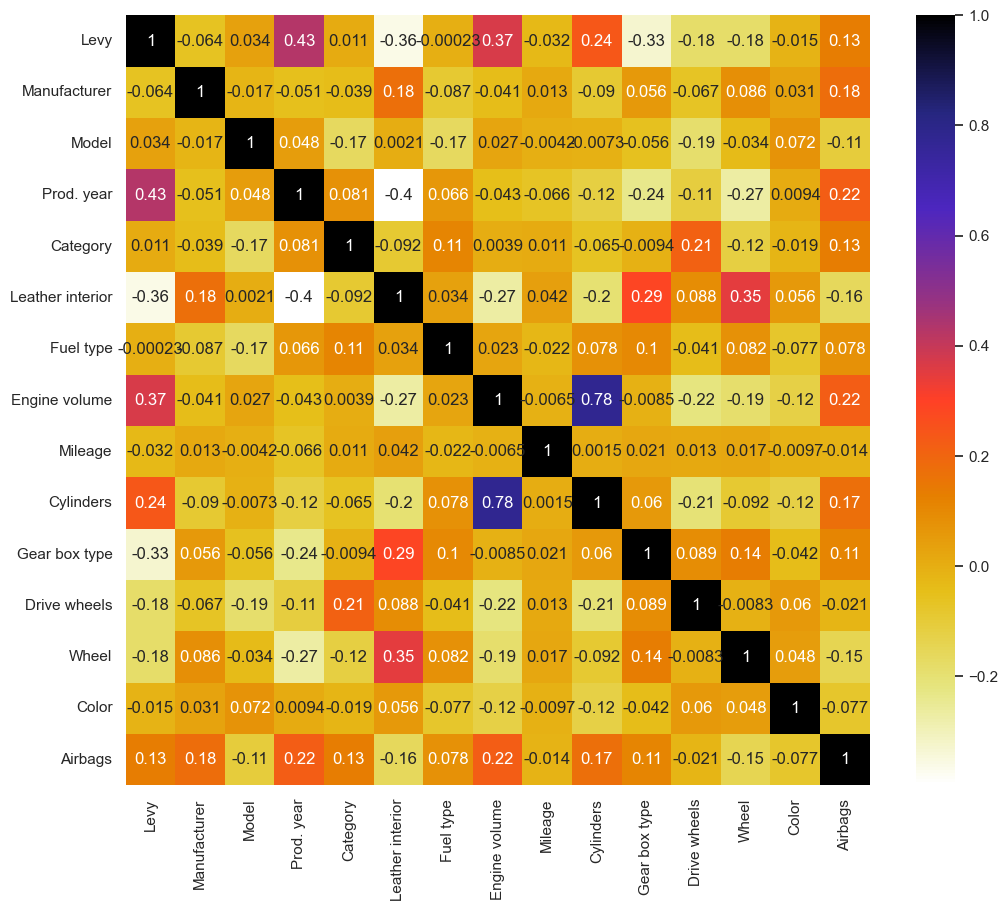

In [59]:
# Compute correlation matrix (Correlation among independent variables)
corr_matrix = X.corr()
corr_matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap=plt.cm.CMRmap_r,annot=True)

### Observation

y variable contains the target variable ('Price') that you want to predict.
X variable contains the independent variables, excluding the target variable.
This separation is a common practice when preparing data for machine learning. It allows you to use X to train a model to predict y.

The heatmap visualization provides a graphical representation of the correlation matrix.

Each cell in the heatmap represents the correlation coefficient between two independent variables.

The color intensity and the annotation inside each cell indicate the strength and direction of correlation.

Positive correlations are indicated by lighter colors, while negative correlations are indicated by darker colors.

A correlation value close to 1 or -1 indicates a strong correlation, while a value close to 0 indicates weak correlation or no correlation.

The diagonal line of the heatmap represents the correlation of each variable with itself, which is always 1.

In [60]:
#This method calculates the correlation coefficient between every pair of columns in the DataFrame.
corr_matrix

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
Levy,1.000000,-0.063922,0.033854,0.428934,0.010836,-0.360055,-0.000229,0.371214,-0.031576,0.237628,-0.327455,-0.182010,-0.183144,-0.015183,0.131658
Manufacturer,-0.063922,1.000000,-0.017038,-0.050689,-0.038951,0.175233,-0.087002,-0.041471,0.013317,-0.090110,0.055739,-0.066787,0.086100,0.031369,0.180558
Model,0.033854,-0.017038,1.000000,0.047798,-0.165203,0.002093,-0.168508,0.027010,-0.004151,-0.007338,-0.056212,-0.185906,-0.033840,0.072101,-0.105155
Prod. year,0.428934,-0.050689,0.047798,1.000000,0.081288,-0.398148,0.066068,-0.043293,-0.066132,-0.117891,-0.239337,-0.109064,-0.270631,0.009422,0.224001
Category,0.010836,-0.038951,-0.165203,0.081288,1.000000,-0.092195,0.112179,0.003950,0.011067,-0.064761,-0.009413,0.212334,-0.119409,-0.019457,0.134615
Leather interior,-0.360055,0.175233,0.002093,-0.398148,-0.092195,1.000000,0.033814,-0.271749,0.041587,-0.199716,0.288333,0.087991,0.346620,0.056343,-0.161889
Fuel type,-0.000229,-0.087002,-0.168508,0.066068,0.112179,0.033814,1.000000,0.022789,-0.021926,0.078438,0.103579,-0.041325,0.081820,-0.077465,0.078033
Engine volume,0.371214,-0.041471,0.027010,-0.043293,0.003950,-0.271749,0.022789,1.000000,-0.006485,0.777228,-0.008490,-0.222393,-0.185995,-0.121863,0.221991
Mileage,-0.031576,0.013317,-0.004151,-0.066132,0.011067,0.041587,-0.021926,-0.006485,1.000000,0.001493,0.021270,0.012650,0.017361,-0.009659,-0.013829
Cylinders,0.237628,-0.090110,-0.007338,-0.117891,-0.064761,-0.199716,0.078438,0.777228,0.001493,1.000000,0.059993,-0.206277,-0.091955,-0.122251,0.174112


In [61]:
#used nested loops to iterate over the upper triangle of the correlation matrix
def correlation(dataset, threshold):
    corr_pairs = tuple()
    all_pairs = []
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                print(abs(corr_matrix.iloc[i, j]))
                corr_pairs = (corr_matrix.columns[i], corr_matrix.columns[j],corr_matrix.iloc[i, j])
                all_pairs.append(corr_pairs)
                return all_pairs

corr_feature_pairs = correlation(X, 0.7)
corr_feature_pairs

0.7772279242475023


[('Cylinders', 'Engine volume', 0.7772279242475023)]

#### OBSERVATION

The provided code defines a function called correlation that takes a dataset and a correlation threshold as input parameters. The function identifies pairs of features in the dataset that have a correlation coefficient greater than the specified threshold.

The function uses nested loops to iterate over the upper triangle of the correlation matrix.
For each pair of features (columns) with a correlation coefficient greater than the specified threshold, it prints the absolute correlation value and adds the feature pair and correlation value to the all_pairs list.

The print(abs(corr_matrix.iloc[i, j])) line is included in the code to display the absolute correlation value for each pair of correlated features

In [62]:
corr_features_to_drop = [ 'Cylinders','Engine volume']
X.drop(corr_features_to_drop,axis=1,inplace=True)
print(X.shape)

(18924, 13)


### Obsevations

The provided code drops two columns, 'Cylinders' and 'Engine volume', from the DataFrame X and then prints the resulting shape of X.

The inplace=True parameter modifies the DataFrame in place, meaning the changes are applied to the original DataFrame X.

The output of print(X.shape) will show the updated shape of X after dropping the specified columns. The number of columns will be reduced by 2 if 'Cylinders' and 'Engine volume' columns existed in the original DataFrame.

###       SECTION 4: Computing correlation of independent feature with dependent variable 'PRICE'

In [63]:
## Split the data into train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

X_train.head(3)

(15139, 13)
(3785, 13)
(15139,)
(3785,)


,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Wheel,Color,Airbags
11090,0.0,36,1277,2000.0,5,0,5,126000.0,0,2,0,14,0
6240,585.0,23,633,2013.0,9,0,5,227853.0,0,1,0,3,12
13058,753.0,23,1334,2012.0,9,0,5,90720.0,0,1,0,2,12


### OBSERVATION

The shapes of X_train, X_test, y_train, and y_test are printed to indicate the number of samples and features in each set.

[X_train.head(3)]: This prints the first 3 rows of the training feature set (X_train). It provides a quick glimpse into the structure and values of the features for the first few observations in the training set.

##### Comment: Selecting 7 most independent feature from the set

In [64]:
#Calculating the correlation between the features in X_train and the target variable y_train.
num_features = 7
corr_with_target = X_train.corrwith(y_train)
corr_with_target

selected_features = corr_with_target.sort_values(ascending=False).head(num_features).index.tolist()
type(selected_features)
selected_features


selected_train_df1=pd.DataFrame(X_train[selected_features])
selected_train_df1

,Gear box type,Prod. year,Drive wheels,Model,Leather interior,Color,Category
11090,0,2000.0,2,1277,0,14,5
6240,0,2013.0,1,633,0,3,9
13058,0,2012.0,1,1334,0,2,9
16498,2,2015.0,1,537,0,2,9
2048,0,2014.0,1,1502,0,3,3
...,...,...,...,...,...,...,...
2136,0,2011.0,2,601,0,12,9
16386,0,2012.0,1,1401,0,1,9
4274,2,2012.0,0,1529,0,7,4
1301,0,2000.0,2,1418,0,14,5


### OBSERVATION

[corr_with_target]:This line calculates the correlation between each feature in X_train and the target variable y_train. The resulting corr_with_target Series contains correlation values for each feature.

[selected_features]: This line sorts the features based on their correlation with the target variable in descending order and selects the top 7 features. The names of these selected features are stored in the selected_features list.

[type(selected_features)]: Prints the type of the selected_features variable, confirming that it's a list.

[selected_train_df1]: Creates a new DataFrame (selected_train_df1) using only the selected features from the original X_train DataFrame.

[selected_train_df1.head()]: Displays the first few rows of the new DataFrame, giving you a glimpse of the selected features for the training data.

###             SECTION 5: Using SelectKBest() Method to Reduce dataset size to 7 Features.

from sklearn.feature_selection import SelectKBest, SelectPercentile,f_regression
from sklearn.feature_selection import mutual_info_regression

In [65]:
sel_cols = SelectKBest(f_regression, k=7)
sel_cols.fit(X_train, y_train)

SelectKBest(k=7, score_func=<function f_regression at 0x0000026C8B1A6160>)

In [66]:
print(X_train.columns[ sel_cols.get_support() ])
sel_cols.get_support()

Index(['Levy', 'Manufacturer', 'Prod. year', 'Gear box type', 'Drive wheels',
       'Wheel', 'Airbags'],
      dtype='object')


array([ True,  True, False,  True, False, False, False, False,  True,
        True,  True, False,  True])

#### OBSERVATION

[sel_cols = SelectKBest(f_regression, k=7)]-This line creates an instance of the SelectKBest class. It is configured to use the f_regression scoring function, which is suitable for regression problems. The k=7 parameter indicates that it should select the top 7 features.

[sel_cols.fit(X_train, y_train)]-The fit method is called on the sel_cols object, where it computes the F-statistic scores for each feature in the training data (X_train) in relation to the target variable (y_train).

I went a head to inspect selected feature using ['get support()'] method,where by the selected_features array will be a boolean, where [True] indicates the selected features and [False] indicates the non-selected features.